# 1. Import Libraries

Mengimpor seluruh library yang diperlukan untuk analisis data, visualisasi, feature engineering, evaluasi model, dan machine learning.

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

Mengunggah dan membaca dataset travel time TransJakarta.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving AI_Engineer_dataset.parquet to AI_Engineer_dataset.parquet


In [5]:
df = pd.read_parquet("AI_Engineer_dataset.parquet")

print(df.shape)

df.head()

(351103, 10)


,bus_body_no,segment_id,route_code,trip_id,stop_sequence,traveling_time_sec,from_arrival_time_str,arrival_time,average_time_sec,no_do
0,BUS-DUMMY-000213,SEG-DUMMY-008872,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,19,219.803,2026-02-25 23:56:25,2026-02-26 00:00:04,270.049170,DO-DUMMY-00299173
1,BUS-DUMMY-000571,SEG-DUMMY-008870,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,5,44.978,2026-02-25 23:59:21,2026-02-26 00:00:06,42.349785,DO-DUMMY-00299198
2,BUS-DUMMY-000587,SEG-DUMMY-009421,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,16,52.956,2026-02-25 23:59:36,2026-02-26 00:00:29,47.706570,DO-DUMMY-00299184
3,BUS-DUMMY-000587,SEG-DUMMY-009422,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,17,44.836,2026-02-26 00:01:10,2026-02-26 00:01:55,50.087549,DO-DUMMY-00299184
4,BUS-DUMMY-000222,SEG-DUMMY-008751,ROUTE-DUMMY-0001,TRIP-DUMMY-000013,19,154.996,2026-02-26 00:00:04,2026-02-26 00:02:39,157.195013,DO-DUMMY-00299174


# 3. Initial Data Understanding

Melihat ukuran dataset dan struktur data.

In [15]:
print(df.shape)

(351103, 10)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351103 entries, 0 to 351102
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   bus_body_no            351103 non-null  object        
 1   segment_id             351103 non-null  object        
 2   route_code             351103 non-null  object        
 3   trip_id                351103 non-null  object        
 4   stop_sequence          351103 non-null  int64         
 5   traveling_time_sec     351103 non-null  float64       
 6   from_arrival_time_str  351103 non-null  object        
 7   arrival_time           351103 non-null  datetime64[ns]
 8   average_time_sec       351103 non-null  float64       
 9   no_do                  351103 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 26.8+ MB


# 4. Data Preparation

Mengubah kolom waktu menjadi format datetime.

In [20]:
df["arrival_time"] = pd.to_datetime(
    df["arrival_time"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351103 entries, 0 to 351102
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   bus_body_no            351103 non-null  object        
 1   segment_id             351103 non-null  object        
 2   route_code             351103 non-null  object        
 3   trip_id                351103 non-null  object        
 4   stop_sequence          351103 non-null  int64         
 5   traveling_time_sec     351103 non-null  float64       
 6   from_arrival_time_str  351103 non-null  object        
 7   arrival_time           351103 non-null  datetime64[ns]
 8   average_time_sec       351103 non-null  float64       
 9   no_do                  351103 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 26.8+ MB


# 5. Missing Value Analysis

Memeriksa apakah terdapat data yang hilang pada setiap kolom.

In [18]:
df.isnull().sum()

,0
bus_body_no,0
segment_id,0
route_code,0
trip_id,0
stop_sequence,0
traveling_time_sec,0
from_arrival_time_str,0
arrival_time,0
average_time_sec,0
no_do,0


# 6. Descriptive Statistics

Melihat statistik dasar dataset untuk memahami karakteristik data.

In [19]:
df.describe()

,stop_sequence,traveling_time_sec,arrival_time,average_time_sec
count,351103.000000,351103.000000,351103,3.511030e+05
mean,12.082121,467.327755,2026-02-15 09:22:45.991330048,4.619165e+02
min,1.000000,0.222000,2026-02-01 00:01:35,9.825727e+00
25%,6.000000,60.365000,2026-02-08 21:25:17,6.266701e+01
50%,12.000000,89.067000,2026-02-15 14:49:54,8.974202e+01
75%,17.000000,165.400500,2026-02-22 08:32:51.500000,1.704753e+02
max,35.000000,958259.716000,2026-03-07 07:16:32,1.095265e+06
std,7.537613,7331.544113,NaN,5.433856e+03


# 7. Travel Time Distribution Analysis

Menganalisis distribusi target untuk mengidentifikasi skewness dan outlier.

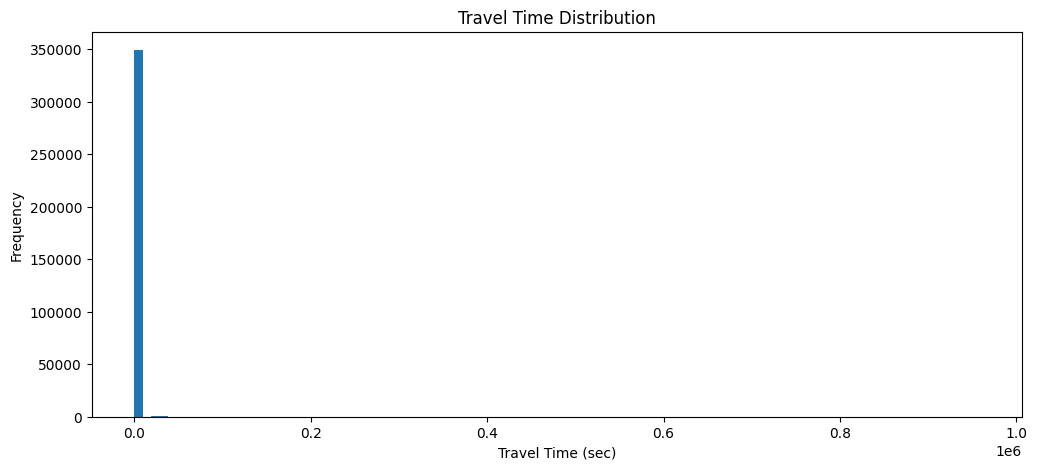

In [21]:
plt.figure(figsize=(12,5))

plt.hist(
    df["traveling_time_sec"],
    bins=100
)

plt.title("Travel Time Distribution")
plt.xlabel("Travel Time (sec)")
plt.ylabel("Frequency")

plt.show()

# 8. Skewness Analysis using Log Transformation

Melihat distribusi target setelah log transformation.

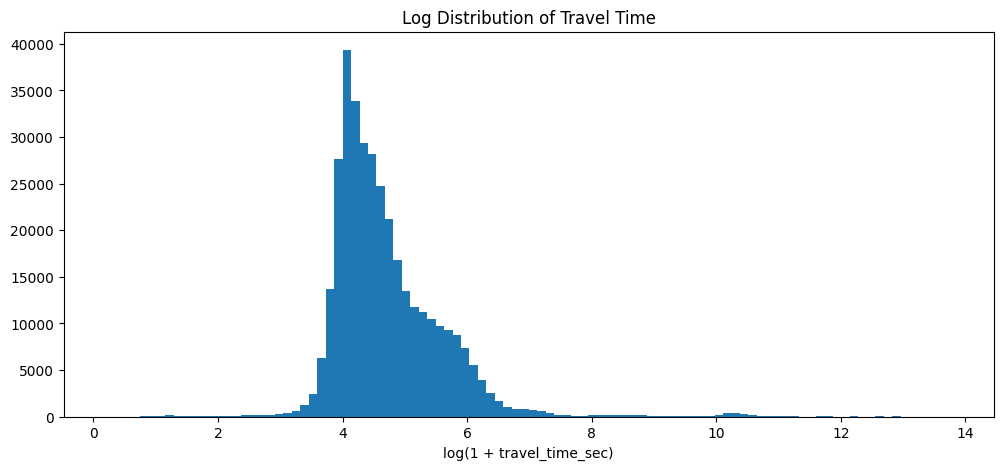

In [22]:
plt.figure(figsize=(12,5))

plt.hist(
    np.log1p(df["traveling_time_sec"]),
    bins=100
)

plt.title(
    "Log Distribution of Travel Time"
)

plt.xlabel(
    "log(1 + travel_time_sec)"
)

plt.show()

# 9. Trip Incompleteness Detection

Mendeteksi kemungkinan hilangnya data halte dalam satu trip.

In [23]:
df = df.sort_values(
    ["trip_id","stop_sequence"]
)

In [24]:
df["seq_diff"] = (
    df.groupby("trip_id")
      ["stop_sequence"]
      .diff()
)

In [25]:
df["is_gap_suspected"] = (
    df["seq_diff"] > 1
).astype(int)

In [26]:
df["is_gap_suspected"].value_counts()

,count
is_gap_suspected,
0,351100
1,3


# 10. Gap Analysis Result

Visualisasi jumlah trip yang memiliki indikasi gap sequence.

In [27]:
gap_count = (
    df["is_gap_suspected"]
      .value_counts()
)

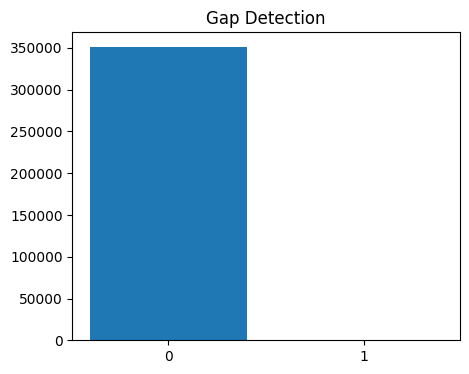

In [28]:
plt.figure(figsize=(5,4))

plt.bar(
    gap_count.index.astype(str),
    gap_count.values
)

plt.title("Gap Detection")

plt.show()

# 11. Outlier Analysis

Menganalisis quantile travel time untuk melihat keberadaan outlier ekstrem.

In [29]:
df["traveling_time_sec"].quantile(
    [0.50,0.75,0.90,0.95,0.99,0.999]
)

,traveling_time_sec
0.500,89.067000
0.750,165.400500
0.900,331.072800
0.950,459.331700
0.990,1909.595940
0.999,44467.100238


# 12. Time-Based Feature Engineering

Membuat fitur waktu yang berpotensi mempengaruhi travel time.

In [30]:
df["hour"] = (
    df["arrival_time"]
      .dt.hour
)

df["day_of_week"] = (
    df["arrival_time"]
      .dt.dayofweek
)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df["is_peak_hour"] = (
    df["hour"].isin(
        [6,7,8,9,16,17,18,19]
    )
).astype(int)

# 13. Travel Time Deviation Analysis

Mengukur deviasi waktu tempuh aktual terhadap rata-rata historis.

In [31]:
df["deviation_ratio"] = (
    df["traveling_time_sec"]
    /
    df["average_time_sec"]
)

In [32]:
df[
[
    "traveling_time_sec",
    "average_time_sec",
    "deviation_ratio"
]
].head()

,traveling_time_sec,average_time_sec,deviation_ratio
707,26606.901,26846.627158,0.991071
882,951.887,8332.785567,0.114234
1329,257.086,466.474153,0.551126
1512,501.687,2574.851692,0.194841
1928,30880.827,25846.945599,1.194757


# 14. Previous Segment Feature

Menggunakan informasi segmen sebelumnya dalam satu trip.

In [33]:
df["prev_travel_time"] = (
    df.groupby("trip_id")
      ["traveling_time_sec"]
      .shift(1)
)

In [34]:
df["prev_travel_time"] = (
    df["prev_travel_time"]
      .fillna(df["average_time_sec"])
)

# 15. Rolling Mean Travel Time

Menghitung rata-rata waktu tempuh beberapa segmen sebelumnya.

In [35]:
df["rolling_mean_3"] = (
    df.groupby("trip_id")
      ["traveling_time_sec"]
      .rolling(3)
      .mean()
      .reset_index(
          level=0,
          drop=True
      )
)

In [36]:
df["rolling_mean_3"] = (
    df["rolling_mean_3"]
      .fillna(df["average_time_sec"])
)

# 16. Segment Frequency Feature

Mengukur kepadatan historis masing-masing segmen.

In [37]:
segment_freq = (
    df["segment_id"]
      .value_counts()
)

In [38]:
df["segment_frequency"] = (
    df["segment_id"]
      .map(segment_freq)
)

# 17. Categorical Encoding

Mengubah fitur kategorikal menjadi format numerik.

In [39]:
le_segment = LabelEncoder()

df["segment_encoded"] = (
    le_segment.fit_transform(
        df["segment_id"]
    )
)

In [40]:
le_route = LabelEncoder()

df["route_encoded"] = (
    le_route.fit_transform(
        df["route_code"]
    )
)

# 18. Feature Selection

In [41]:
features = [

    "average_time_sec",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "segment_encoded",
    "route_encoded",
    "segment_frequency",
    "prev_travel_time",
    "rolling_mean_3",
    "is_gap_suspected"

]

# 19. Target Transformation

In [42]:
X = df[features]

y_log = np.log1p(
    df["traveling_time_sec"]
)

# 20. Train Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

# 21. XGBoost Model Training

In [44]:
model_log = XGBRegressor(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1

)

model_log.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

# 22. Prediction

In [45]:
pred_log = model_log.predict(
    X_test
)

pred = np.expm1(pred_log)

actual = np.expm1(y_test)

# 23. Model Evaluation

In [46]:
mae = mean_absolute_error(
    actual,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

mape = mean_absolute_percentage_error(
    actual,
    pred
)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 221.93007354292055
RMSE : 6033.102736362443
MAPE : 0.2804310692869328


# 24. Feature Importance Analysis

In [47]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model_log.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
0,average_time_sec,0.582134
9,rolling_mean_3,0.261331
8,prev_travel_time,0.079917
1,hour,0.019878
5,segment_encoded,0.019465
7,segment_frequency,0.013989
4,is_peak_hour,0.010614
2,day_of_week,0.006836
3,is_weekend,0.005836
6,route_encoded,0.000000


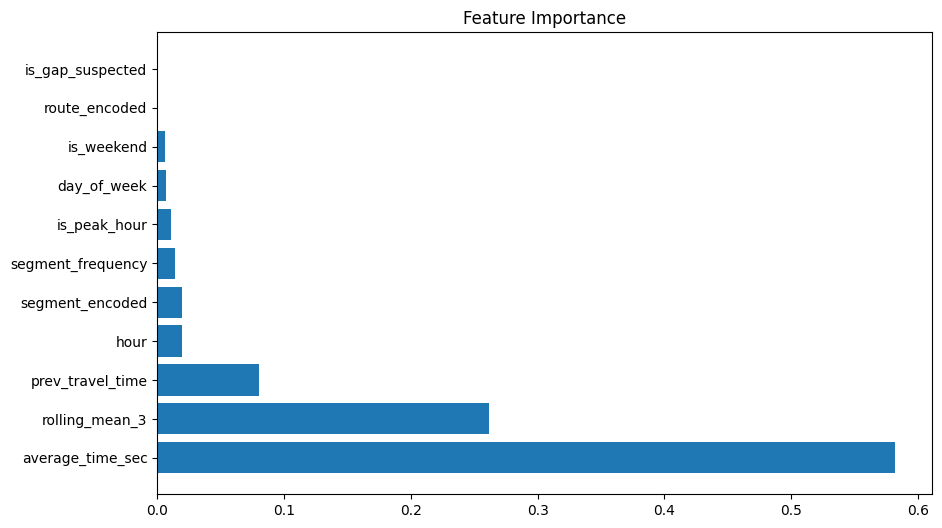

In [48]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

# 25. Trip-Level Evaluation

In [49]:
trip_eval = pd.DataFrame({
    "trip_id": df.loc[X_test.index, "trip_id"],
    "actual": actual,
    "pred": pred
})

In [50]:
trip_eval = (
    trip_eval
    .groupby("trip_id")
    .agg({
        "actual":"sum",
        "pred":"sum"
    })
    .reset_index()
)

In [51]:
trip_mae = mean_absolute_error(
    trip_eval["actual"],
    trip_eval["pred"]
)

print(
    "Trip MAE :",
    trip_mae
)

Trip MAE : 786249.27477571


# 26. Save Model and Processed Dataset

In [52]:
output_df = df[
[
    "trip_id",
    "segment_id",
    "traveling_time_sec",
    "average_time_sec",
    "deviation_ratio",
    "is_gap_suspected"
]
]

In [53]:
output_df.to_csv(
    "processed_dataset.csv",
    index=False
)

In [54]:
joblib.dump(
    model_log,
    "xgboost_travel_time_model.pkl"
)

['xgboost_travel_time_model.pkl']

# 27. Conclusion

## Key Findings

1. Tidak ditemukan missing value pada dataset.
2. Hanya ditemukan 3 gap sequence dari 351.103 observasi.
3. Distribusi travel time sangat skewed dan ditangani menggunakan log transformation.
4. average_time_sec, rolling_mean_3, dan prev_travel_time merupakan fitur paling berpengaruh.
5. Model XGBoost menghasilkan MAE 221.93 detik dan MAPE 28.04%.
6. Ensemble LSTM + XGBoost direkomendasikan untuk implementasi produksi karena mampu menangkap pola tabular dan sekuensial secara bersamaan.